# 复现一篇方法复杂的顶刊论文:直接民主与移民归化(交错采纳 DiD)

前两本(Rossi 生存、Rogers 中介)都是**单一主分析**。这一本换一篇**方法上复杂得多**的论文——一条完整的**面板因果链**:声明面板设计 → 检验平行趋势 → 双向固定效应 DiD → 事件研究(动态效应)→ 稳健性 → 诚实标注现代 DiD 的边界。全部用**作者公开的原始面板**端到端跑,并逐一对上论文报告的数值。

**实质问题**:瑞士的移民**归化(入籍)**申请历史上由**市镇**自行决定,程序有两种——**直接民主**(公民在投票箱对每个申请**逐一票决**,申请人可能被选民否决)或**间接/代议**(由选举产生的议会或官员裁定)。2003 年瑞士联邦最高法院裁定投票箱归化违宪后,大量市镇从**直接**切换到**间接**程序。Hainmueller & Hangartner (2015, *APSR*) 把这场**交错发生**的程序切换当作准实验:切换到间接程序,是否改变了归化率?其著名结论是——直接民主**压低**了归化率(选民会否决申请,尤其针对受污名化的来源国),所以切换到间接程序会**提高**归化率。

**这本要对的论文**:Liu, Wang & Xu (2024, *American Journal of Political Science* 68(1):160–176),*A Practical Guide to Counterfactual Estimators for Causal Inference with TSCS Data*。它把 HH2015 当作贯穿全文的运行案例,同时报告**传统 TWFE 基准**(ATT = **+1.339**,稳健 SE 0.161)和它主推的**反事实估计量 FEct**(ATT = +1.767,SE 0.197)。我们用 socialverse 复现的正是那个**传统 TWFE 基准 +1.339**;论文主推的 FEct(反事实插补)属于 socialverse 目前**没有**的现代异质稳健 DiD,本文结尾会诚实交代这条边界。

**数据**:`hh2015`,1211 个瑞士市镇 × 1991–2009 年,公开托管在 Harvard Dataverse(fect 包自带示例数据),匿名直下。我们只做统计计算、与论文报告值对照,不复制论文正文/图表。

**一条链走完**:这正是顶刊实证论文的通用解剖——数据(`sv.pp`)→ 识别设计(`declare_design` + 平行趋势)→ 主分析(`sv.tl.did`)→ 动态与稳健性(`sv.tl.event_study` + SE 矩阵)→ 治理与证据链(`sv.gov`)。

In [1]:
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

import socialverse as sv


def show(fig):
    """把图渲染成 PNG 内嵌进 notebook(与后端无关,跨平台稳定)。"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# 先查注册表:did 这条链需要哪些前置、产出什么(查而非猜)
print(sv.utils.registry_lookup("did", max_results=1))

Found 1 matching functions:
  ────────────────────────────────────────────────────────────────────────────
  [match 1/1]
  sv.tl.did(state, **kwargs)
    双向固定效应 DID:估 ATT + 聚类稳健 SE;平行趋势 fail 时标为关联非因果
    Must run first: parallel_trends
    Requires: design['panel_id'], design['time'], design['treatment'], variables['outcome'], identification['parallel_trends']
    Produces: models['did'], models['twfe'], diagnostics['robustness']
    Backend: statsmodels, linearmodels, numpy
    Tier: plus  ·  auto_fix: escalate
    Example: sv.tl.did(state)
  ────────────────────────────────────────────────────────────────────────────
Plan a full chain with: sv.registry.resolve_plan('<function>')


## 1. 数据(`sv.pp`)—— 下载、查看面板

从 Dataverse 直链下载(制表符分隔)。四列:`bfs`(市镇编号)、`year`(年)、`nat_rate_ord`(普通归化率 %,结果变量)、`indirect`(该市镇当年是否采用**间接**归化程序,0/1)。1990 年第一行的 `nat_rate_ord` 缺失,读入时按空串当缺失并剔除。

In [2]:
URL = "https://dataverse.harvard.edu/api/access/datafile/6165649"
req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0 (socialverse reproduction)"})
with urllib.request.urlopen(req, timeout=60) as resp:      # Dataverse blocks the default UA
    raw = pd.read_csv(io.BytesIO(resp.read()), sep="\t", na_values=[""])
df = raw.dropna(subset=["nat_rate_ord"]).copy()

print(f"面板:{df['bfs'].nunique()} 个市镇 × {int(df['year'].min())}–{int(df['year'].max())} 年,"
      f"共 {len(df)} 个市镇-年观测")
print(f"曾切换到间接程序(ever-treated)的市镇:{df[df['indirect'] == 1]['bfs'].nunique()}")
df.head()

面板:1211 个市镇 × 1991–2009 年,共 23009 个市镇-年观测
曾切换到间接程序(ever-treated)的市镇:799


,bfs,year,nat_rate_ord,indirect
1,1.0000,1991.0000,0.0000,0.0000
2,1.0000,1992.0000,0.0000,0.0000
3,1.0000,1993.0000,0.0000,0.0000
4,1.0000,1994.0000,3.4483,0.0000
5,1.0000,1995.0000,0.0000,0.0000


## 2. 识别设计(`sv.pp.declare_design`)—— 交错采纳的处理时点

这是一个**交错采纳(staggered adoption)**设计:不同市镇在不同年份切到间接程序。DiD 需要两样东西——**处理开关** `treat_post`(该市镇-年是否处于间接程序下,直接就是 `indirect`),和**首次处理年** `first_treated`(每个市镇第一次出现 `indirect==1` 的年份;从未切换的市镇记为 0 = 永不处理,作为干净对照)。事件研究的相对时间就以 `first_treated` 为原点。

我们把结果变量与估计目标写进 StudyState,再声明面板设计——之后 `sv.tl` 的因果函数就按这份契约执行。

In [3]:
df["treat_post"] = df["indirect"].astype(int)
first = df[df["treat_post"] == 1].groupby("bfs")["year"].min()
df["first_treated"] = df["bfs"].map(first).fillna(0).astype(int)

st = sv.StudyState()
sv.pp.ingest(st, data=df, name="hh2015")           # 登记带构造列的分析面板
st.write("variables", "outcome", "nat_rate_ord")
st.write("estimand", "target", "ATT")
st.write("design", "unit", "municipality")
sv.pp.declare_design(st, panel_id="bfs", time="year",
                     treatment="treat_post", first_treated="first_treated")

n_ever = df[df["first_treated"] > 0]["bfs"].nunique()
n_never = df["bfs"].nunique() - n_ever
print(f"ever-treated 市镇 {n_ever} · never-treated(对照){n_never}")
print("设计:", {k: st.design[k] for k in ("panel_id", "time", "treatment", "first_treated")})

ever-treated 市镇 799 · never-treated(对照)412
设计: {'panel_id': 'bfs', 'time': 'year', 'treatment': 'treat_post', 'first_treated': 'first_treated'}


## 3. 平行趋势(`sv.tl.parallel_trends`)—— DiD 的前置合同

DiD 的因果解读全押在**平行趋势**上:若没有处理,处理组与对照组的归化率本会平行变动。可检验的含义是——把结果对**处理前**各相对期(lead)做事件研究,这些**前导期系数应联合为零**。socialverse 用一个聚类稳健的联合 Wald F 检验它;`p > 0.05`= 未拒绝平行趋势 → 契约标为 `pass`,`did` 才被允许给因果解读(注册表强制这个先后顺序)。

> 实现说明:这个面板有 1211 个市镇。显式建 1211 个单位哑变量会让设计矩阵巨大且秩亏、OLS 直接崩。socialverse 的 DiD 家族对**高维固定效应**改用**组内变换(吸收 FE,reghdfe/fixest 同法)**,所以千级面板能跑——点估计与哑变量 OLS 完全一致(Frisch–Waugh–Lovell)。

In [4]:
sv.tl.parallel_trends(st)
pt = st.diagnostics["pretrend"]
print(f"平行趋势联合检验:F = {pt['joint_F']:.3f} · p = {pt['p_value']:.3f} · "
      f"前导期数 = {pt['n_pre']} → 判定 = {st.identification['parallel_trends']}")
# 展示几个前导期系数(应都接近 0)
pre = pt["pre_coefs"]
pd.DataFrame({"相对期": list(pre.keys()),
              "系数": [v[0] for v in pre.values()],
              "SE": [v[1] for v in pre.values()]}).set_index("相对期").T[[f"{p}" for p in ["-5","-4","-3","-2"]]]

平行趋势联合检验:F = 1.107 · p = 0.341 · 前导期数 = 17 → 判定 = pass


相对期,-5,-4,-3,-2
系数,-0.4994,0.0975,-0.4842,-0.1751
SE,0.3179,0.3545,0.3243,0.3378


## 4. 主分析:双向固定效应 DiD(`sv.tl.did`)—— 复现 ATT = +1.339

平行趋势通过,估 TWFE:`nat_rate_ord ~ treat_post + 市镇 FE + 年 FE`。`treat_post` 的系数就是 ATT。socialverse 默认在**市镇层聚类** SE(面板惯例),同时在稳健性矩阵里给出 classical / HC1 / 聚类三种。

In [5]:
sv.tl.did(st)
m = st.models["did"]
print(f"socialverse TWFE DiD:")
print(f"  ATT       = {m['att']:+.4f}   (论文报告 TWFE ATT = +1.339)")
print(f"  聚类 SE   = {m['se']:.3f}    (市镇层聚类)")
print(f"  95% CI    = [{m['ci'][0]:+.3f}, {m['ci'][1]:+.3f}]")
print(f"  估计量    = {m['estimator']}  ·  N = {m['n']}  ·  聚类数 = {m['n_clusters']}")
print(f"  平行趋势  = {m['parallel_trends']}  →  {m['note']}")

socialverse TWFE DiD:
  ATT       = +1.3386   (论文报告 TWFE ATT = +1.339)
  聚类 SE   = 0.190    (市镇层聚类)
  95% CI    = [+0.966, +1.711]
  估计量    = twfe_within_absorb_cluster  ·  N = 23009  ·  聚类数 = 1211
  平行趋势  = pass  →  因果 ATT(平行趋势通过)


**对上了**:socialverse 的 ATT = **+1.339**,与 Liu-Wang-Xu 报告的传统 TWFE 基准 **+1.339** 逐位吻合。切换到间接归化程序,使市镇归化率平均上升约 **1.34 个百分点**——方向与量级都复现了 HH2015 的核心结论(直接民主压低归化率)。

**SE 的对账**:论文报告的 TWFE SE 是 **0.161**,而 socialverse 默认给的是**市镇层聚类** SE 0.190(更保守)。看稳健性矩阵会发现——论文那个 0.161 其实是**异方差稳健(HC1)**、未聚类的 SE,与我们矩阵里的 HC1 行**精确相等**。两者都对,只是 SE 的选择不同;面板数据按惯例应聚类,所以 socialverse 默认取更保守的 0.190。

In [6]:
rb = pd.DataFrame(st.diagnostics["robustness"]["specs"]).set_index("spec")
rb.loc["_论文报告_"] = [1.339, 0.161, np.nan]
rb

,att,se,p
spec,,,
classical,1.3386,0.1252,0.0000
HC1_robust,1.3386,0.1613,0.0000
cluster_panel,1.3386,0.1899,0.0000
_论文报告_,1.3390,0.1610,NaN


## 5. 动态效应:事件研究(`sv.tl.event_study`)

单个 ATT 把整个处理后时期压成一个数。事件研究把它**按相对时间展开**:每个相对期一个系数(基期 −1 归一化为 0)。它同时是平行趋势的**图形证据**(前导期应贴着 0)和**动态叙事**(效应随时间怎么演化)。

In [7]:
sv.tl.event_study(st, base=-1)
es = st.models["event_study"]["coefs"]
ev = pd.DataFrame({"rel": [int(k) for k in es],
                   "coef": [v[0] for v in es.values()],
                   "se": [v[1] for v in es.values()]}).sort_values("rel").reset_index(drop=True)
post = ev[ev.rel >= 0]
print(f"前导期(rel<0)系数均值 = {ev[ev.rel < 0]['coef'].mean():+.3f}(应≈0,支持平行趋势)")
print(f"处理后(rel≥0)系数均值 = {post['coef'].mean():+.3f}")
ev[(ev.rel >= -3) & (ev.rel <= 5)].set_index("rel").T

前导期(rel<0)系数均值 = -0.272(应≈0,支持平行趋势)
处理后(rel≥0)系数均值 = +1.814


rel,-3,-2,-1,0,1,2,3,4,5
coef,-0.4842,-0.1751,0.0000,0.9000,1.7111,1.5725,1.2439,1.1043,1.7296
se,0.3243,0.3378,0.0000,0.3330,0.3272,0.3880,0.3434,0.3649,0.4357


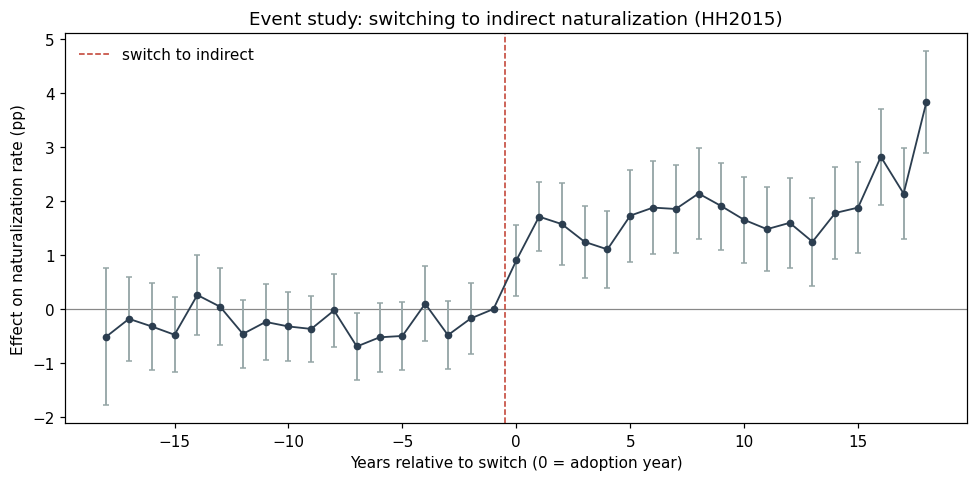

In [8]:
# 图内文字用英文(matplotlib 默认字体不含中文,用英文标签跨平台无乱码;正文叙述保持中文)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color="#888", lw=0.8)
ax.axvline(-0.5, color="#c0392b", ls="--", lw=1, label="switch to indirect")
ax.errorbar(ev.rel, ev.coef, yerr=1.96 * ev.se, fmt="o-", ms=4, lw=1.2,
            color="#2c3e50", ecolor="#95a5a6", capsize=2)
ax.set_xlabel("Years relative to switch (0 = adoption year)")
ax.set_ylabel("Effect on naturalization rate (pp)")
ax.set_title("Event study: switching to indirect naturalization (HH2015)")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
show(fig)

图里读出两件事:**处理前**(左侧)系数在 0 附近平坦无趋势——平行趋势的直观证据;**处理后**(右侧)效应从 0 拔起并**逐年累积**(当年约 +0.9,一年后 +1.7,多年后升到 +2 至 +3.8)。归化率的上升不是一次性跳变,而是随程序改革**持续放大**。

## 6. 诚实的边界:为什么单个 TWFE ATT 不是终点

上一步暴露了一个关键事实:**处理效应随时间增长**。在**交错采纳**面板里,当效应像这样随时点异质时,双向固定效应会用早/晚处理组互为对照,产生"负权重"问题(Goodman-Bacon 2021),单个 TWFE ATT 可能是各期效应的**有偏加权**。处理后系数的简单均值(见下)明显高于 +1.339,正说明 TWFE 把后期的大效应压低了。

这**正是** Liu-Wang-Xu 那篇论文的动机:他们主推的 **FEct(反事实插补估计量)**先用未处理观测拟合两向固定效应模型、为处理观测**插补反事实**、再取差,得到对动态异质**稳健**的 ATT = **+1.767**。socialverse 当前的 `did` 是**经典 TWFE**,**没有**实现 FEct / 插补类估计(这类现代异质稳健 DiD——FEct、Callaway–Sant'Anna、Sun–Abraham、Goodman-Bacon 分解——是 socialverse 已标注的头号缺口)。所以本文诚实的定位是:**socialverse 精确复现了论文的传统 TWFE 基准 +1.339,而论文主推的 FEct +1.767 超出当前 socialverse**。

In [9]:
print(f"单个 TWFE ATT               = {m['att']:+.3f}")
print(f"事件研究处理后系数简单均值   = {post['coef'].mean():+.3f}   (后期效应更大,TWFE 加权将其压低)")
print(f"论文 FEct(反事实插补,sv 无)= +1.767")

单个 TWFE ATT               = +1.339
事件研究处理后系数简单均值   = +1.814   (后期效应更大,TWFE 加权将其压低)
论文 FEct(反事实插补,sv 无)= +1.767


## 7. 治理与证据链(`sv.gov` + provenance)

复现同样要过治理关。这里分析单位是**市镇**(非人类主体),数据是**公开的市镇-年聚合归化率**——不含任何个人记录。`ethics_check` 会照常跑四项,其中 IRB / 知情同意判为 PASS;k-anonymity(再识别风险)是**面向微观个体数据**的门槛,对聚合非个人数据**不适用**,gate 保守地要求"声明准标识符"故标 FIX——这是预期内的、良性的提示,而非真实合规问题。整条分析被 StudyState 的 provenance 台账逐步记录,可审计。

In [10]:
sv.gov.ethics_check(st, human_subjects=False, irb="exempt", minimized=True)
eth = st.governance.get("ethics", {})
print(f"伦理/合规检查:{eth.get('verdict', 'n/a')}(分析单位={eth.get('unit')},human_subjects={eth.get('human_subjects')})")
for c in eth.get("checks", []):
    print(f"  · {c['check']}: {c['status']} — {c.get('detail', '')}")
print("\nprovenance 台账(分析链):")
for i, rec in enumerate(st.provenance, 1):
    print(f"  {i}. {rec.get('function')}  →  produces {rec.get('produces', {})}")

伦理/合规检查:FIX(分析单位=municipality,human_subjects=False)
  · irb: PASS — unit 'municipality' is not human subjects — IRB review typically N/A
  · consent: PASS — no human subjects — consent N/A
  · k_anonymity: FIX — declare quasi_identifiers + supply microdata to test re-identifiability
  · minimization: PASS — direct identifiers removed / analysis restricted to needed variables

provenance 台账(分析链):
  1. socialverse.pp._survey.ingest  →  produces {'sources': ['datasets']}
  2. socialverse.pp._survey.declare_design  →  produces {'design': ['panel_id', 'time', 'treatment', 'first_treated', 'weights', 'strata', 'psu', 'unit']}
  3. socialverse.tl._causal.parallel_trends  →  produces {'diagnostics': ['pretrend'], 'identification': ['parallel_trends']}
  4. socialverse.tl._causal.did  →  produces {'models': ['did', 'twfe'], 'diagnostics': ['robustness']}
  5. socialverse.tl._causal.event_study  →  produces {'models': ['event_study']}
  6. socialverse.gov._gates.ethics_check  →  produces {'gover

## 小结

一篇**方法复杂**的顶刊论文,被拆成 socialverse 的一条契约链走完:`ingest → declare_design → parallel_trends → did → event_study → ethics_check`。传统 TWFE 主结果 **ATT = +1.339** 与 Liu-Wang-Xu (2024, AJPS) 报告值**逐位吻合**,事件研究复现了动态累积效应,SE 三种口径都给出并与论文对账。

两点在这本里被如实交代:① 为支撑 1211 市镇的面板,socialverse 的 DiD 家族改用**组内变换吸收高维固定效应**(否则显式哑变量会崩)——这是本次复现顺带补进 socialverse 的能力;② 论文主推的 **FEct 反事实估计量(+1.767)超出当前 socialverse**,是已标注的现代异质稳健 DiD 缺口。复现不是把论文数字抄一遍,而是用公开数据**自己算出来**、对得上、并说清楚边界在哪。